In [1]:
########## import some useful package ##########

import time
t1 = time.time()

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import ripser
import persim

In [2]:
########## read the data ##########

sig_processes = ["hhvv", "hhmumu"]
processes = ["jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_type = [str(i)+"_500K" for i in processes]

BR_hbb = 0.5824
Xsection = [1.08143e-1, 3.539e-2, 1.86879e-2, 2.200885e+1, 7.053723e+1, 1.3355, 3.983523e+1, 7.03508147*BR_hbb]     ### unit: fb
sig_Xsection = [0.327342*BR_hbb*BR_hbb, 4.945395e-2*BR_hbb*BR_hbb]    ### hhvv and hhmumu
Luminosity = 1000   ### unit: fb^-1
sig_simulation_num = 100000
simulation_num = 500000

features = ["VLCjetR10N2", "VLCjetR10N2.PT", "VLCjetR10N2.Eta", "VLCjetR10N2.Phi", "VLCjetR10N2.Mass", "MissingET.MET", "VLCjetR10N2.BTag"]

##### set data path #####

event_path = []
event_path.append("/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv/Events/run_06_decayed_1/delphes_events.root")
event_path.append("/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu/Events/run_06_decayed_1/delphes_events.root")
for type in event_type:
    event_path.append("/data/mucollider/two_boosted/10TeV/" + type + "/delphes_output.root")

##### get the data file #####

data_file =[]
for path in event_path:
    data_file.append(uproot.open(path))
    
##### read data with features #####

Xsection = sig_Xsection + Xsection
processes = sig_processes + processes

events = []     ### total events
for process in processes:
    tmp_events = []
    for feature in features:
        tmp_events.append(data_file[processes.index(process)]["Delphes;1"][feature].array())
    tmp_events = np.expand_dims(tmp_events, axis=-1)
    tmp_events = tmp_events.transpose((1,0,2))
    tmp_events = np.squeeze(tmp_events,axis=(2,))
    events.append(tmp_events)
del tmp_events

print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:32.8690 (s)


In [3]:
len(events)

10

In [4]:
########## define useful function ##########

##### calculate significance #####

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

##### count event number #####

def count(events):
    events_num = []
    for i, process in enumerate(processes):
        events_num.append(len(events[processes.index(process)]))
        if (process=="hhvv" or process=="hhmumu"):
            print("There are", events_num[i], process, "events. Corresponding cross section:", Xsection[processes.index(process)]*events_num[i]/sig_simulation_num, "(fb)")
        else:
            print("There are", events_num[i], process, "events. Corresponding cross section:", Xsection[processes.index(process)]*events_num[i]/simulation_num, "(fb)")
        
##### select if Fat Jet >= 2 #####
        
def Fat_Jet_selection(events):
    where1 = np.where(events[:,features.index("VLCjetR10N2")]>=2)
    return events[where1]

##### select if M_jet_leading > XX GeV #####

def mass_leading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][0]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][0]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if M_jet_subleading > XX GeV #####

def mass_subleading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][1]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][1]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_leading > XX GeV #####

def pT_leading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][0]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][0]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_subleading > XX GeV #####

def pT_subleading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][1]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][1]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### define X_HH (defined in 2207.09602v2) #####

def calculate_X_HH(event):
    jet_mass1 = event[features.index("VLCjetR10N2.Mass")][0]
    jet_mass2 = event[features.index("VLCjetR10N2.Mass")][1]
    diff1 = np.abs(jet_mass1 - 124)
    diff2 = np.abs(jet_mass2 - 124)
    if diff1<diff2:
        m1 = jet_mass1
        m2 = jet_mass2
    else:
        m1 = jet_mass2
        m2 = jet_mass1
    return np.sqrt(((m1-124)/(0.1*m1+0.00001))**2 + ((m2-115)/(0.1*m2+0.00001))**2)

##### calculate M_JJ #####

def calculate_M_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    M_JJ = np.sqrt(p[0]**2 - p[1]**2 - p[2]**2 - p[3]**2)
    return M_JJ

##### calculate pT_JJ #####

def calculate_pT_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    pT_JJ = np.sqrt(p[1]**2 + p[2]**2)
    return pT_JJ

##### calculate \Delta_\Eta #####

def calculate_dEta_JJ(event):
    return np.abs(event[features.index("VLCjetR10N2.Eta")][0] - event[features.index("VLCjetR10N2.Eta")][1])

##### select if 2 Jets pass BTag WP70 #####

def two_BTag_selection(event):
    where1 = []
    for i in range(len(event)):
        BTag_leading = event[i][features.index("VLCjetR10N2.BTag")][0]
        BTag_subleading = event[i][features.index("VLCjetR10N2.BTag")][1]
        if (((BTag_leading&2)==2) and ((BTag_subleading&2)==2)):
            where1.append(i)
    return event[where1]

In [5]:
########## preselection ##########

print("Before any selection:")
count(events)

##### 2 fat jet selection #####

for process in processes:
    events[processes.index(process)] = Fat_Jet_selection(events[processes.index(process)])
print("\nAfter 2 fat jet selection:")
count(events)

Before any selection:
There are 100000 hhvv events. Corresponding cross section: 0.11103105441792002 (fb)
There are 100000 hhmumu events. Corresponding cross section: 0.016774273431552 (fb)
There are 500000 jjBG_ptcut events. Corresponding cross section: 0.108143 (fb)
There are 500000 ttBG_ptcut events. Corresponding cross section: 0.03539 (fb)
There are 500000 bbBG_ptcut events. Corresponding cross section: 0.0186879 (fb)
There are 500000 wwBG events. Corresponding cross section: 22.00885 (fb)
There are 500000 wwvvBG events. Corresponding cross section: 70.53723 (fb)
There are 500000 zzBG events. Corresponding cross section: 1.3355 (fb)
There are 500000 zzvvBG events. Corresponding cross section: 39.83523 (fb)
There are 500000 hzvvBG events. Corresponding cross section: 4.097231448128 (fb)

After 2 fat jet selection:
There are 99805 hhvv events. Corresponding cross section: 0.11081454386180509 (fb)
There are 99849 hhmumu events. Corresponding cross section: 0.01674894427867036 (fb)
Th

In [6]:
########## visualization of kinematics ##########

m_J_leading = []
m_J_subleading = []
pt_J_leading = []
pt_J_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_m1 = []
    tmp_m2 = []
    tmp_pt1 = []
    tmp_pt2 = []
    for i in range(len(events[processes.index(process)])):
        tmp_m1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][0])
        tmp_m2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][1])
        tmp_pt1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][0])
        tmp_pt2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][1])
    m_J_leading.append(tmp_m1)
    m_J_subleading.append(tmp_m2)
    pt_J_leading.append(tmp_pt1)
    pt_J_subleading.append(tmp_pt2)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
del tmp_m1, tmp_m2, tmp_pt1, tmp_pt2

Time:34.5914 (s)
Time:34.8056 (s)
Time:35.8957 (s)
Time:37.0271 (s)
Time:38.1835 (s)
Time:38.8996 (s)
Time:39.9826 (s)
Time:40.7785 (s)
Time:41.8978 (s)
Time:43.1377 (s)


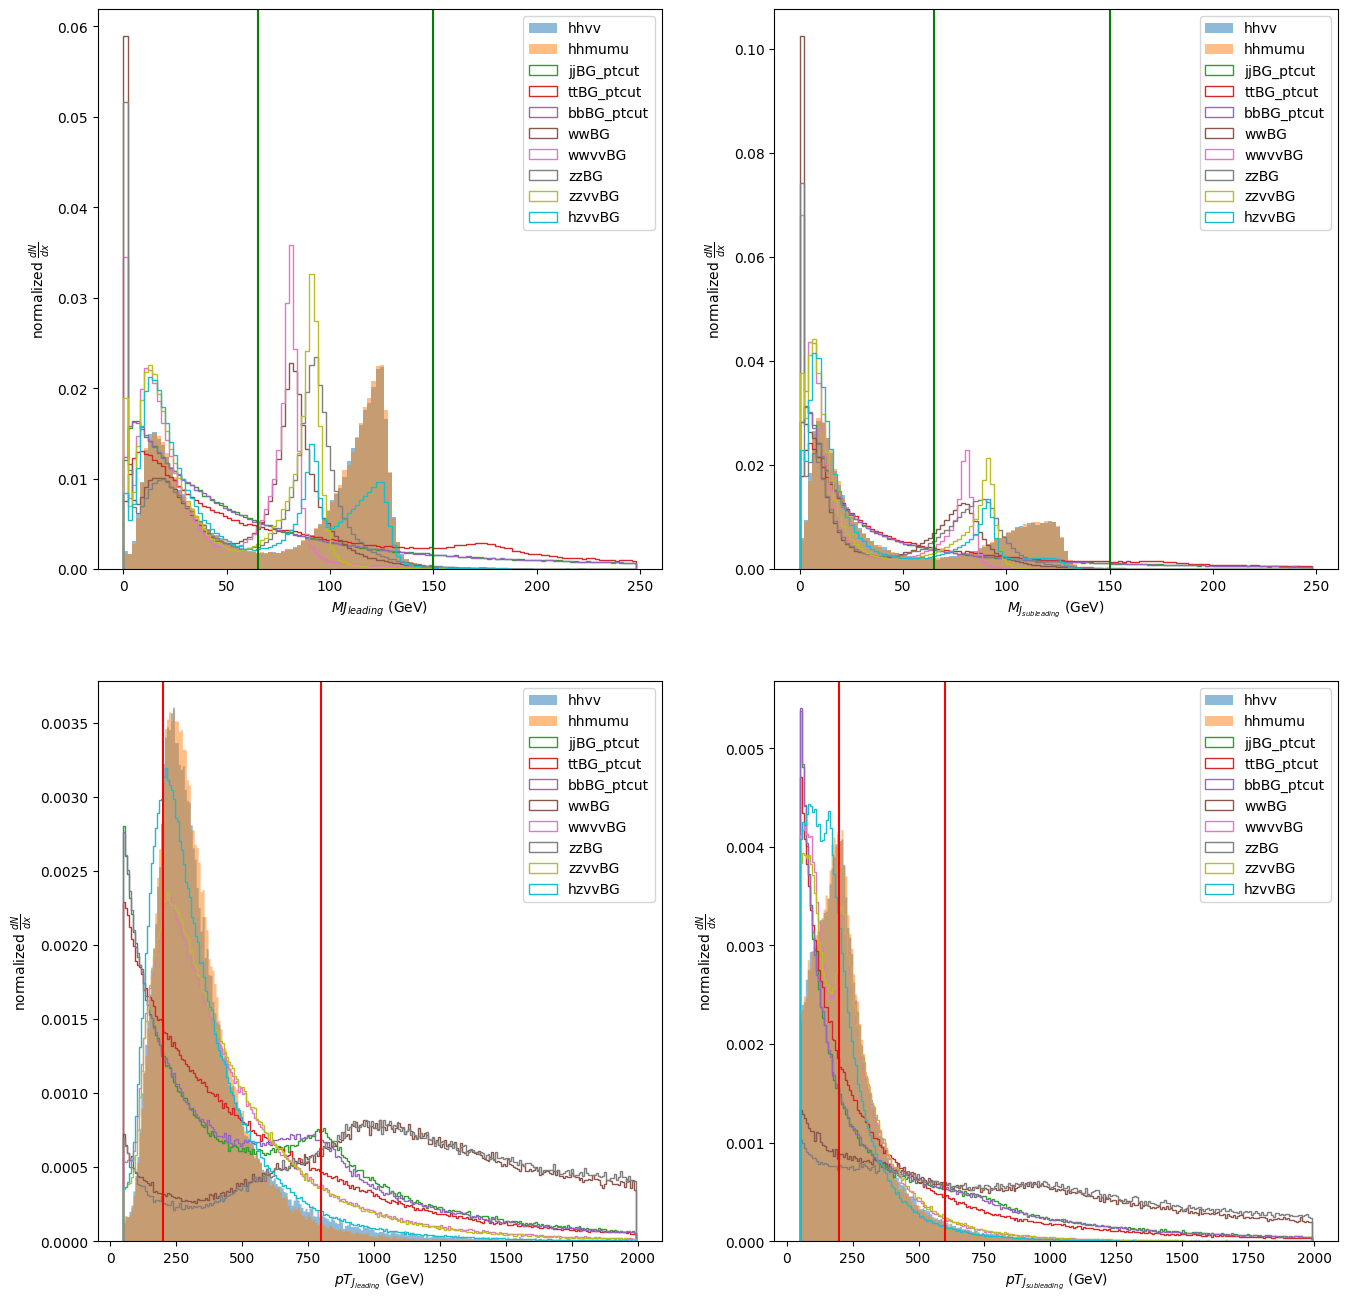

In [16]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 16))

fig.add_subplot(221)     ### plot leading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(222)     ### plot subleading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(223)     ### plot leading jet PT
bins = np.arange(50,2000,7.5)
for process in processes:
    plt.hist(pt_J_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(800, color='r')
plt.xlabel(r"$pT_{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(224)     ### plot subleading jet PT
bins = np.arange(50,2000,7.5)
for process in processes:
    plt.hist(pt_J_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(600, color='r')
plt.xlabel(r"$pT_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

plt.show()

In [8]:
########## Do some basic cuts ##########

##### leading jet pT selection #####

leading_low_pT_cut = 200   ### GeV
leading_high_pT_cut = 800   ### GeV
for process in processes:
    events[processes.index(process)] = pT_leading_selection(events[processes.index(process)], leading_low_pT_cut, leading_high_pT_cut)
print("\nAfter leading jet pT selection:")
count(events)

##### subleading jet pT selection #####

subleading_low_pT_cut = 200   ### GeV
subleading_high_pT_cut = 600   ### GeV
for process in processes:
    events[processes.index(process)] = pT_subleading_selection(events[processes.index(process)], subleading_low_pT_cut, subleading_high_pT_cut)
print("\nAfter subleading jet pT selection:")
count(events)

##### leading jet mass selection #####

leading_low_mass_cut = 65
leading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_leading_selection(events[processes.index(process)], leading_low_mass_cut, leading_high_mass_cut)
print("\nAfter leading jet mass selection:")
count(events)

##### subleading jet mass selection #####

subleading_low_mass_cut = 65
subleading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_subleading_selection(events[processes.index(process)], subleading_low_mass_cut, subleading_high_mass_cut)
print("\nAfter subleading jet mass selection:")
count(events)


After leading jet pT selection:
There are 76939 hhvv events. Corresponding cross section: 0.08542618295860349 (fb)
There are 79745 hhmumu events. Corresponding cross section: 0.013376644347991143 (fb)
There are 179100 jjBG_ptcut events. Corresponding cross section: 0.0387368226 (fb)
There are 219735 ttBG_ptcut events. Corresponding cross section: 0.015552843299999999 (fb)
There are 187318 bbBG_ptcut events. Corresponding cross section: 0.0070011601044 (fb)
There are 41554 wwBG events. Corresponding cross section: 1.8291115058 (fb)
There are 299330 wwvvBG events. Corresponding cross section: 42.22781811179999 (fb)
There are 36406 zzBG events. Corresponding cross section: 0.09724042599999999 (fb)
There are 308477 zzvvBG events. Corresponding cross section: 24.57650448942 (fb)
There are 338299 hzvvBG events. Corresponding cross section: 2.772178603340509 (fb)

After subleading jet pT selection:
There are 42506 hhvv events. Corresponding cross section: 0.047194859990881084 (fb)
There are 

In [9]:
########## visualization of other kinematics ##########

missET = []
X_HH = []
M_JJ = []
pT_JJ = []
dEta_JJ = []
BTag_leading = []
BTag_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_met = []
    tmp_X_HH = []
    tmp_M_JJ = []
    tmp_pT_JJ = []
    tmp_dEta_JJ = []
    tmp_Btag_0 = []
    tmp_Btag_1 = []
    for i in range(len(events[processes.index(process)])):
        tmp_met.append(events[processes.index(process)][i][features.index("MissingET.MET")][0])
        tmp_X_HH.append(calculate_X_HH(events[processes.index(process)][i]))
        tmp_M_JJ.append(calculate_M_JJ(events[processes.index(process)][i]))
        tmp_pT_JJ.append(calculate_pT_JJ(events[processes.index(process)][i]))
        tmp_dEta_JJ.append(calculate_dEta_JJ(events[processes.index(process)][i]))
        tmp_Btag_0.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][0])
        tmp_Btag_1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][1])
    missET.append(tmp_met)
    X_HH.append(tmp_X_HH)
    M_JJ.append(tmp_M_JJ)
    pT_JJ.append(tmp_pT_JJ)
    dEta_JJ.append(tmp_dEta_JJ)
    BTag_leading.append(tmp_Btag_0)
    BTag_subleading.append(tmp_Btag_1)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
    
del tmp_met, tmp_X_HH, tmp_M_JJ, tmp_pT_JJ, tmp_dEta_JJ, tmp_Btag_0, tmp_Btag_1

Time:140.0540(s)
Time:142.7117(s)
Time:143.8604(s)
Time:145.9884(s)
Time:147.2167(s)
Time:147.2178(s)
Time:153.5959(s)
Time:153.5984(s)
Time:161.7340(s)
Time:169.3686(s)


/usr/local/lib/python3.8/dist-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.8/dist-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.8/dist-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


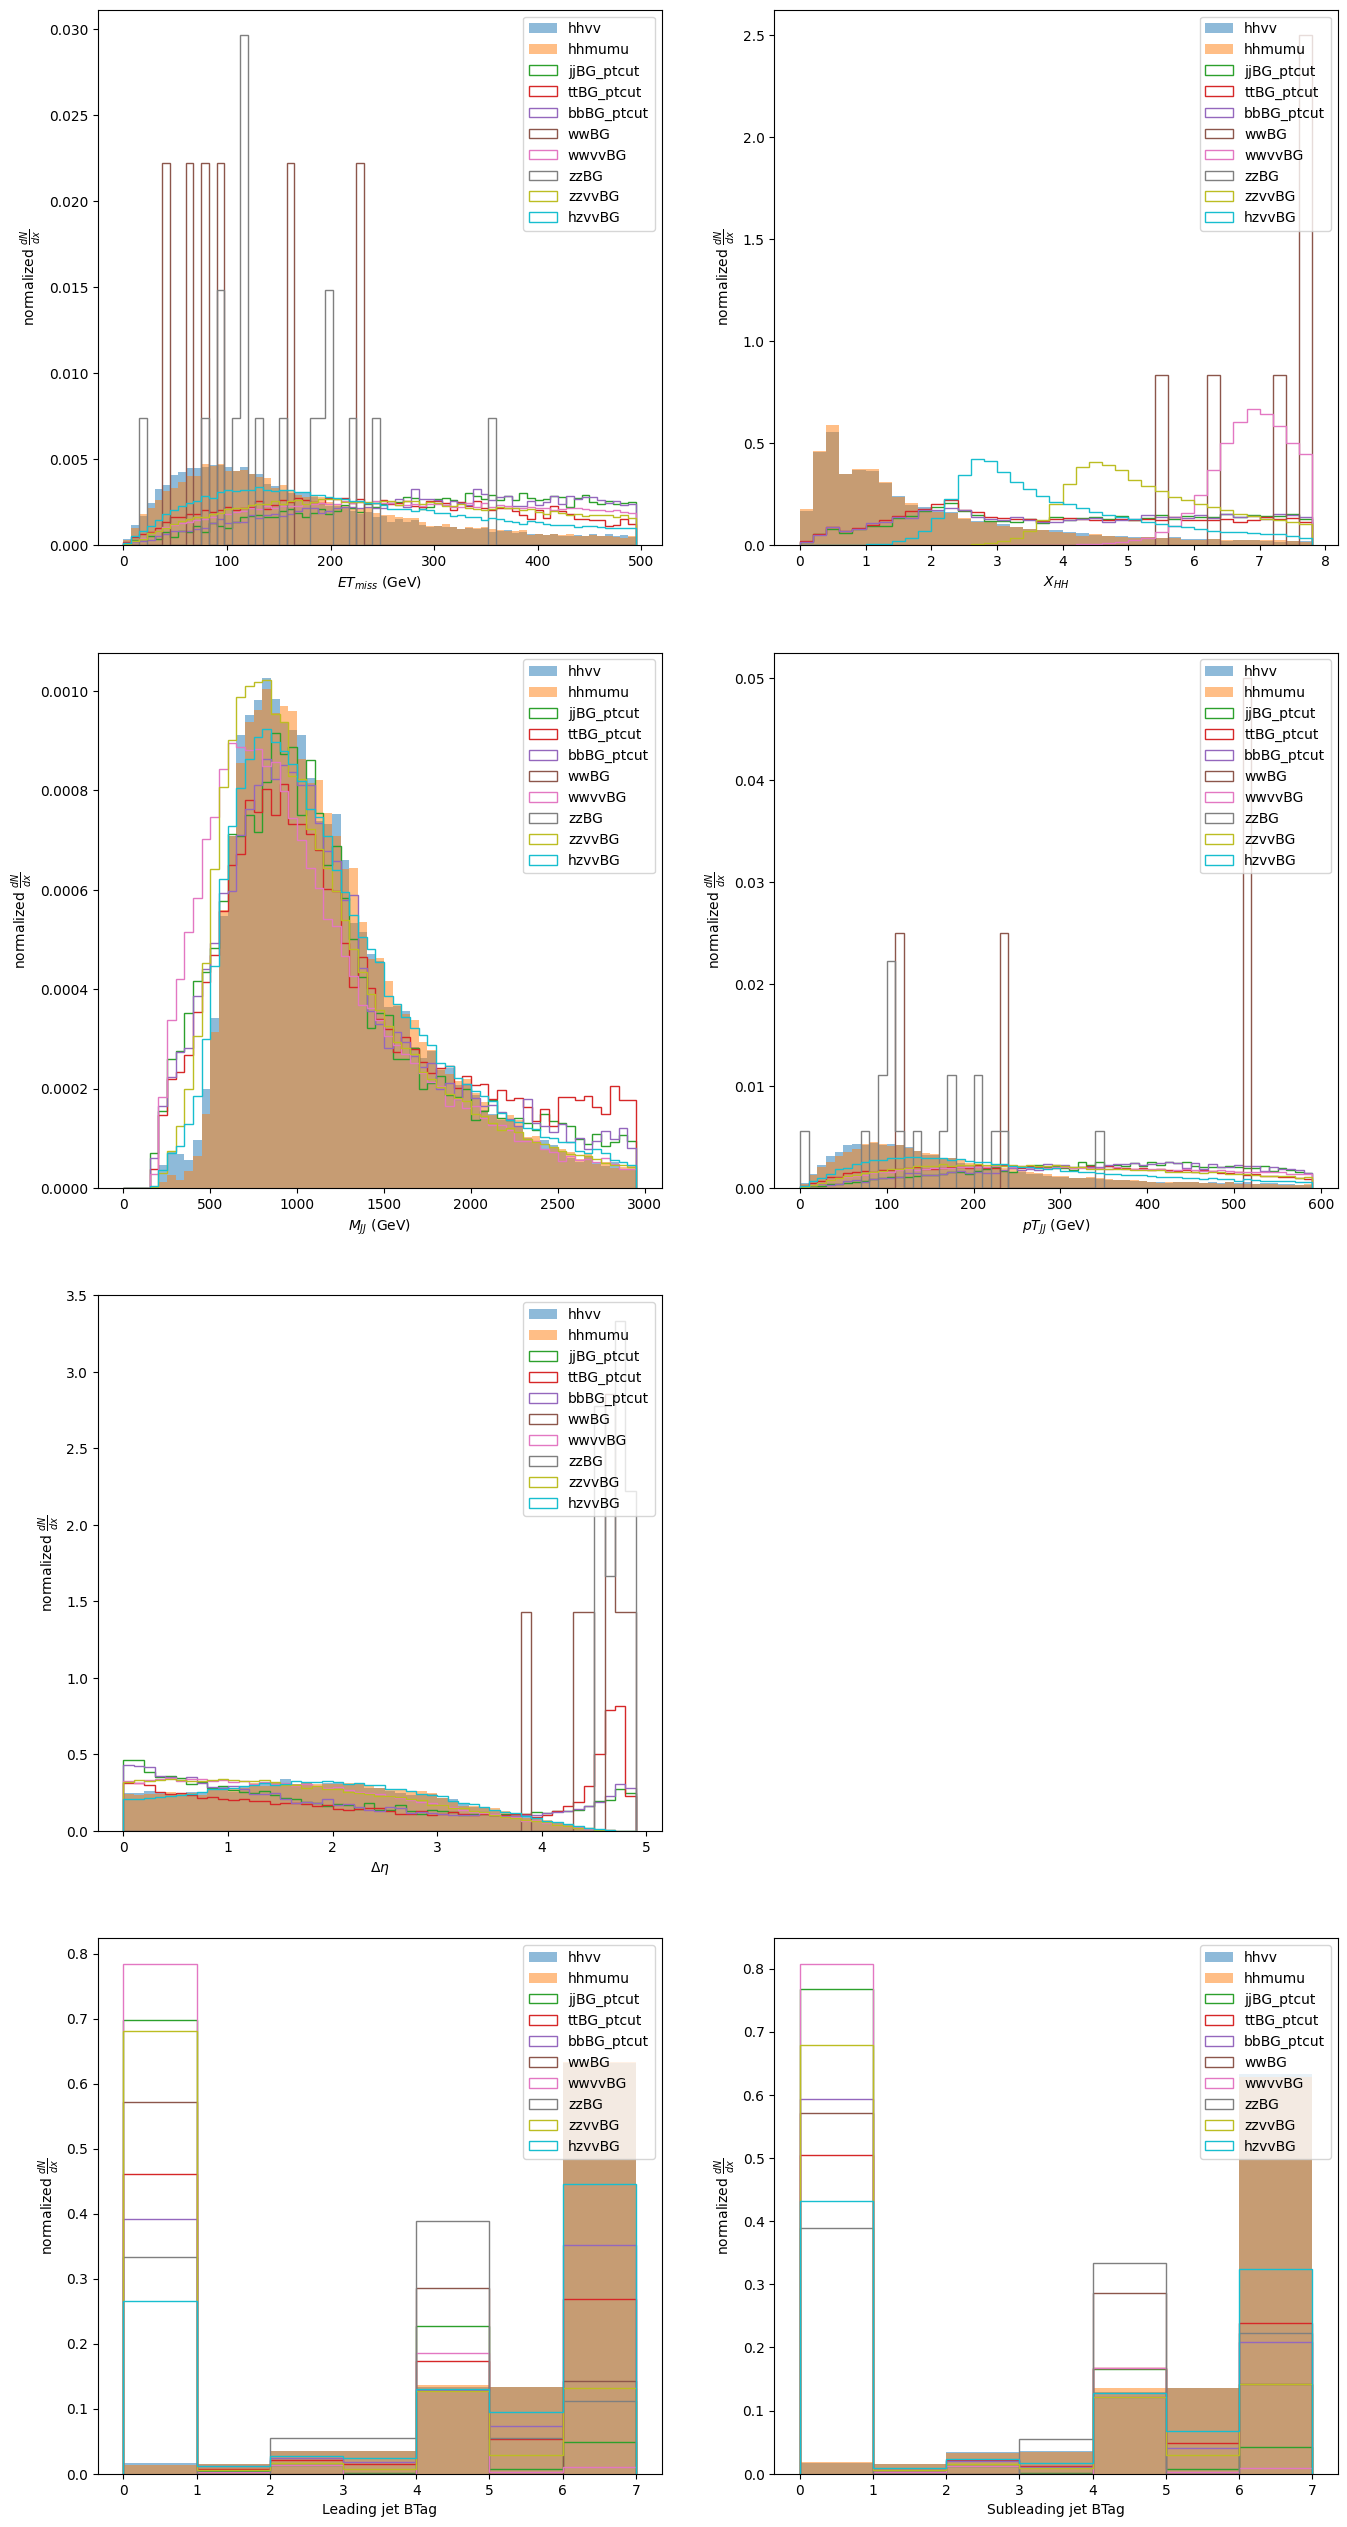

In [10]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 32))

fig.add_subplot(421)     ### plot MET
bins = np.arange(0,500,7.5)
for process in processes:
    plt.hist(missET[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$ET_{miss} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(422)     ### plot X_HH
bins = np.arange(0,8,0.2)
for process in processes:
    plt.hist(X_HH[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$X_{HH}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(423)     ### plot M_JJ
bins = np.arange(0,3000,50)
for process in processes:
    plt.hist(M_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$M_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(424)     ### plot pT_JJ
bins = np.arange(0,600,10)
for process in processes:
    plt.hist(pT_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$pT_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(425)     ### plot dEta_JJ
bins = np.arange(0,5,0.1)
for process in processes:
    plt.hist(dEta_JJ[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$\Delta \eta$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(427)     ### plot BTag of leading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_leading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Leading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

fig.add_subplot(428)     ### plot BTag of subleading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_subleading[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Subleading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend()

plt.show()

In [11]:
##### two BTag selection #####

for process in processes:
    events[processes.index(process)] = two_BTag_selection(events[processes.index(process)])
print("After 2 BTag selection:")
count(events)

After 2 BTag selection:
There are 11197 hhvv events. Corresponding cross section: 0.012432147163174504 (fb)
There are 11903 hhmumu events. Corresponding cross section: 0.0019966417665576346 (fb)
There are 53 jjBG_ptcut events. Corresponding cross section: 1.1463158e-05 (fb)
There are 1358 ttBG_ptcut events. Corresponding cross section: 9.611924e-05 (fb)
There are 812 bbBG_ptcut events. Corresponding cross section: 3.03491496e-05 (fb)
There are 0 wwBG events. Corresponding cross section: 0.0 (fb)
There are 33 wwvvBG events. Corresponding cross section: 0.004655457179999999 (fb)
There are 1 zzBG events. Corresponding cross section: 2.671e-06 (fb)
There are 2010 zzvvBG events. Corresponding cross section: 0.1601376246 (fb)
There are 7858 hzvvBG events. Corresponding cross section: 0.06439208943877965 (fb)


In [12]:
# data_file[processes=="hhvv"]["Delphes;1"].show()

##### show the event #####

events[0][4]

array([2, array([537.698  , 456.86902], dtype=float32),
       array([1.2320439, 1.0164261], dtype=float32),
       array([ 0.25843185, -2.9967952 ], dtype=float32),
       array([126.41695, 120.74284], dtype=float32),
       array([117.22193], dtype=float32), array([7, 7], dtype=uint32)],
      dtype=object)

In [13]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:179.0769(s)
